# MULTI-TARGET TRACKING WITH A RADAR SENSOR

Questo codice è una dimostrazione relativa all'implementazione di un sistema multi-target tracking che utilizza un sensore radar.
Gli algoritmi che permettono di eseguire il tracking sono:
+ Predictor: Kalman Predictor
+ Updater: Extended Kalman Updater
+ Associator: Joint Probabilisti Data Associator (JPDA)


In [61]:
## General Imports:


from datetime import datetime 
from datetime import timedelta 
import numpy as np 
import random

# Stone Soup Imports:

from stonesoup.types.state import State, GaussianState
from stonesoup.types.array import StateVector, CovarianceMatrix
from stonesoup.models.transition.linear import (CombinedLinearGaussianTransitionModel, ConstantVelocity)
from stonesoup.models.measurement.nonlinear import CartesianToElevationBearingRange
from stonesoup.deleter.time import UpdateTimeStepsDeleter
from stonesoup.tracker.simple import MultiTargetMixtureTracker

## I parametri di seguito riportati permettono di modificare parametri relativi alla simulazione del ground truth


In [62]:
## Params setting

start_time = datetime.now() # Time initialization
np.random.seed(73)
random.seed(567)
initial_number_targets = 4 # Initial number of target in the area for the ground truth sim

## Definizione dell'istanza relativa alla piattaforma
La piattaforma viene utilizzata per posizionare il sensore su di essa con il fine di poter acquisire le varie misure.
L'istanza platform_state_vector della classe StateVector permette di definire la posizione della piattaforma nello spazio.
StateVector è un wrapper per numpy.ndarray assicurando che questo sia inizializzato come vettore Nx1 e migliora il processo di indexing.

In [63]:
## Stationary Platform (0,0,0)

platform_state_vector = StateVector([[0],[0],[0]]) # Station postion in the area

position_mapping = (0, 1, 2) # 0-->x; 1-->y; 2-->z of the SS StateVector (used params)


platform_state = State(platform_state_vector, start_time) # Initial state of the platfor

from stonesoup.platform.base import FixedPlatform

# Istance of FixedPlatform class with the params defined before

platform = FixedPlatform(
    
    states = platform_state,
    position_mapping = position_mapping
    
)

## Definizione del radar

Questa sezione prevede la definizione del radar e delle sue specifiche. In particolare è stato adottata la classe RadarElevationBearingRange che permette di definire un sensore che genera misure in accordo con il modello CartesianToElevationBearingRange (modello reversibile).

### Modello di Misura CartesianToElevationBearingRange

Questa è l'implementazione di una classe di un modello di misura invariante nel tempo, in cui si assume che le misure siano ricevute sotto forma di rilevamento ($\phi$), elevazione ($\theta$) e distanza ($r$), con rumore Gaussiano in ogni dimensione.

Il modello è descritto dalle seguenti equazioni:

$$\vec{y}_t = h(\vec{x}_t, \vec{v}_t)$$

Dove:

*   **$\vec{y}_t$** è un vettore di misura della forma:
    $$\vec{y}_t = \begin{bmatrix} \theta \\ \phi \\ r \end{bmatrix}$$

*   **$h$** è una funzione di modello non lineare della forma:
    $$h(\vec{x}_t, \vec{v}_t) = \begin{bmatrix} asin(z / \sqrt{x^2 + y^2 + z^2}) \\ atan2(y, x) \\ \sqrt{x^2 + y^2 + z^2} \end{bmatrix} + \vec{v}_t$$

*   **$\vec{v}_t$** è distribuito secondo una Gaussiana con covarianza $R$, ovvero:
    $$\vec{v}_t \sim \mathcal{N}(0, R)$$
    
    $$R = \begin{bmatrix} \sigma_{\theta}^2 & 0 & 0 \\ 0 & \sigma_{\phi}^2 & 0 \\ 0 & 0 & \sigma_{r}^2 \end{bmatrix}$$

---

### Mapping
La proprietà `mapping` del modello è un vettore di 3 elementi, i cui elementi:
1.  Il primo (`mapping[0]`)
2.  Il secondo (`mapping[1]`)
3.  Il terzo (`mapping[2]`)

Contengono rispettivamente l'indice di stato delle coordinate $x$, $y$ e $z$.

Di fondamentale importanza è il parametro noise_covar utilizzato per definire l'istanza della classe perché è il parametro principale di modeling del sensore. Il rumore in una dimensione (ad esempio l'elevazione θ) è considerato completamente indipendente dal rumore nelle altre dimensioni.
Il metodo measure() viene utilizzato per generato una misura dato un certo stato del target con relativo timestamp ricavato dallo stato. Ogni misura memorizza il GT path che l'ha generata. Ritorna il tipo TrueDetection, deriva da Detection.

#### Detection

Stato utilizzato per detection, contiene:
1. state_vector
2. timestamp
3. measurement_model
4. metadata

## Definizione del clutter

Modello per la generazione di sensor clutter (falsi allarmi) tramite la definizione della distribuzione dello stesso sullo spazio delle misure, del clutter rate e del massimo range relativo alla distribuzione sulle tre dimensioni.
Il metodo function() permette di generare clutter simulato sulla base dei parametri forniti in fase di creazione istanza. Il clutter viene ritornato al sensore chiamante affinché possa essere aggiunto alle true detections. Ritorna tipo "Clutter", parametricamente simile all'oggetto Detection ma diverso per identificativo.

In [64]:
## Radar params and creation

from stonesoup.sensor.radar.radar import RadarElevationBearingRange
from stonesoup.models.clutter import ClutterModel  # To generate clutter directly from the sensor

# Covariance matrix: variance of each radar measure (elev., bear., range)

noise_covar = CovarianceMatrix(np.array(np.diag([np.deg2rad(0.15)**2,np.deg2rad(0.15)**2,25**2])))

radar_mapping = (0, 2, 4)

# Clutter max spatial range definition

params = ((-10000, 10000),  # clutter min x and max x
          (-10000, 10000),  # clutter min y and max y
          (8000, 10000))  # clutter min z and max z

# Istance of ClutterModel class 

clutter_model = ClutterModel(
    
     clutter_rate = 0.5, # Average number of clutter points per time step
     distribution = np.random.default_rng().uniform, # distribution of the clutter over the measurement space
     dist_params = params # required parameters for the clutter distribution function
)

# Istance of RadarElevationBearingRange

radar = RadarElevationBearingRange(
    
    ndim_state = 6, # Number of state dimensions. This is utilised by the underlying CartesianToBearingRange model.
    position_mapping = radar_mapping, #Mapping between the target’s state space and the sensor’s measurement capability
    noise_covar = noise_covar, # sensor noise covariance matrix utilised by the underlying CartesianToElevationBearingRange model
    clutter_model = clutter_model
    
)

platform.add_sensor(radar) # Method for of platform object to add the sensor to the platform

## Simulazione delle traiettorie reali ed acquisizione dati sensore

### Modello di transizione

L'istanza CombinedLinearGaussianTransitionModel permette di utilizzare più modelli di transizione, in questo caso CostantVelocity, definiti sulle tre coordinate per definire il movimento dei target nello spazio tridimensionale.
La classe ConstantVelocity implementa un modello di transizione di velocità costante lineare, Gaussiano, discreto e tempo variante su una dimensione. Un oggetto della classe GaussianState, descritto da una distribuzione gaussiana permette di stabilire gli stati iniziali dei target per mezzo di uno stato definito e di una matrice di covarianza per generare dispersione.
Tra i diversi metodi a disposizione, functin() permette di ritornare lo StateVector tramite la funzione del modello utilizzata.



### Simulatore per il GT

Permette la generazione di traiettorie ground truth tramite i parametri definiti. Il metodo groundtruth_paths_gen() ritorna un generatore di GT per ogni timestamp (timestamp, set(GroundTruthPath)).


### Detection misure sensore

Viene poi definita la classe PlatformDetectionSimulator che permette, data la piattaforma ed il sensore definiti prima, di generare e collezionare le detection del sensore sulla base del groundtruth processato, chiamando ogni sensore montato sulla piattaforma (ovviamente solo il radar in questo caso).
Il metodo "detections_gen()" permette di ritornare le detection per ogni timestamp: (datetime.datetime, Detection).


In [65]:
## Simulation

# Istance of CombinedLinearGaussianTransitionModel
# Combine multiple models into a single model by stacking them. The assumption is that all models are Linear and Gaussian.
# The target is assumed to move with (nearly) constant velocity, where target acceleration is modelled as white noise.


transition_model = CombinedLinearGaussianTransitionModel([ConstantVelocity(0.5), ConstantVelocity(0.5), ConstantVelocity(0.1)])


# Istance of GaussianState
# Gaussian State type
# This is a simple Gaussian state object which is described by a Gaussian state distribution.

initial_target_state = GaussianState(
    
    state_vector = StateVector([[0], [0], [0], [0], [9000], [0]]),
    covar = CovarianceMatrix(np.diag([2000, 50, 2000, 50, 100, 1]))
)

from stonesoup.simulator.simple import MultiTargetGroundTruthSimulator

# Istance of MultiTargetGroundTruthSimulator
# Target simulator that produces multiple targets.
# Targets are created and destroyed randomly, as defined by the birth rate and death probability.

groundtruth_sim = MultiTargetGroundTruthSimulator (
    
    transition_model = transition_model,  # Target transition model
    initial_state = initial_target_state,  # Initial state for targets
    timestep = timedelta(seconds = 1),  # Time between measurements
    initial_number_targets = initial_number_targets,  # Start with tot targets at t0
    number_steps = 200,  # 2 minutes
    birth_rate = 0.05,  # 5% chance of a new target being born every second
    death_probability = 0.02  # 2% chance of a target being killed
    
)


from stonesoup.simulator.platform import PlatformDetectionSimulator

# Istance of Platform detection simulator.
# Processes ground truth data and generates Detection data according to a list of platforms by calling each sensor in these platforms.

sim = PlatformDetectionSimulator(
    
    groundtruth = groundtruth_sim,
    platforms = [platform]
)

## Set Up dell'algoritmo di tracking

Questa sezione definisce gli algoritmi utilizzati per:
1. Effettuare la prediction dello stato al passo k+1 mediante KalmanPredictor ed il modello di transizione utilizzato dai target. Tuttavia nelle applicazioni reali, spesso non è nota questa informazione.
2. Effettuare l'update mediante un ExtendedKalmanUpdater, definendo una nuova matrice di covarianza che sostituisce quella utilizzata per modellare il radar per simulare condizioni di funzionamento in condizioni di confidenza nei confronti delle misure prodotte peggiori rispetto alla varianza prodotta effettivamente dal radar.

Queste istanze vengono utilizzate nelle fasi successive, dopo la definizione dell'Hypothesiser, per creare l'istanza dell'algoritmo di tracking mediante JPDA.

### Predictor

Un **Predictor** viene utilizzato per `prevedere un nuovo `State` (Stato) partendo da uno `State` precedente (*prior*) e un `TransitionModel` (Modello di Transizione)`. 

#### Equazione di Predizione

La predizione dello stato al tempo $k$ dato il tempo $k-1$ è definita come:
$$\mathbf{x}_{k|k-1} = f_k(\mathbf{x}_{k-1}, \nu_k) + b_k(\mathbf{u}_k, \eta_k)$$

**Definizioni dei componenti:**
*   **$\mathbf{x}_{k-1}$**: lo stato precedente (*prior state*).
*   **$f_k(\mathbf{x}_{k-1})$**: la funzione di transizione.
*   **$\mathbf{u}_k$**: il vettore di controllo (influenza esterna).
*   **$b_k(\mathbf{u}_k)$**: l'input di controllo.
*   **$\nu_k$ e $\eta_k$**: rispettivamente il rumore del modello di transizione e del modello di controllo.

#### Kalman Predictor

Una classe predittore che costituisce la base per la famiglia dei predittori di Kalman. Questa classe funge anche da classe (specifica) del Filtro di Kalman `Predictor`. Qui i modelli di transizione e di controllo devono essere lineari:

$$f_k(\mathbf{x}_{k-1}, \nu_k) = F_k\mathbf{x}_{k-1} + \nu_k, \quad \nu_k \sim \mathcal{N}(0, Q_k)$$
$$b_k(\mathbf{u}_k, \eta_k) = B_k(\mathbf{u}_k + \eta_k), \quad \eta_k \sim \mathcal{N}(0, \Gamma_k).$$

Tramite il metodo abstract "predict", è possibile ritornare la prediction di tipo  "StatePrediction" (time and a state vector).

### Updater

L'updater è utilizzato per `eseguire l'update dello stato predetto utilizzando una misura ed un modello di misura`:

$$\mathbf{z} = h(\mathbf{x}, \sigma)$$

dove $\mathbf{x}$ è lo stato, $\sigma$ il rumore di misura e $\mathbf{z}$ la misura risultante.

Il metodo abstract "update" ritorna l'update state sotto formo di tipo "State". Questo metodo chiama prima predict_measurement() per ottene la misura predetta sulla base dello stato predetto dal predictor e dal measurement model utilizzato. 

Gli updater di Kalman assumono $h(\mathbf{x}) = H\mathbf{x}$ con rumore additivo $\sigma = \mathcal{N}(0, R)$. Le classi figlie possono sovrascrivere per specificare un modello di misura più generale $h(\mathbf{x})$.

`update()` chiamando `predict_measurement()`, procede calcolando la misura predetta, la covarianza dell'innovazione e la cross-covarianca della misura:

$$\mathbf{z}_{k|k-1} = H_k\mathbf{x}_{k|k-1}$$
$$S_k = H_k P_{k|k-1} H_k^T + R_k$$
$$\Upsilon_k = P_{k|k-1} H_k^T$$

dove $P_{k|k-1}$ è la covarianza dello stato predetta. `predict_measurement()` restituisce un `GaussianMeasurementPrediction`. Il guadagno di Kalman viene quindi calcolato come,

$$K_k = \Upsilon_k S_k^{-1}$$

e la media e la covarianza dello stato a posteriori sono,

$$\mathbf{x}_{k|k} = \mathbf{x}_{k|k-1} + K_k(\mathbf{z}_k - H_k\mathbf{x}_{k|k-1})$$
$$P_{k|k} = P_{k|k-1} - K_k S_k K_k^T$$

Vengono ritornate come oggetti GaussianStateUpdate.

#### Extended Kalman Updater

Versione estesa del filtro predecentemente descritto con la differenza che il modello di misura può essere non lineare ma deve essere differenziabile affinché possa essere calcolato lo Jacobiano mediante jacobian() per la linearizzazione di h(x).


In [66]:
### Tracking Algorithm

## Kalman Predictor

from stonesoup.predictor.kalman import KalmanPredictor

# Istance of KalmanPredictor

# This class also serves as the Kalman Filter Predictor class. Here transition and control models must be linear.

predictor = KalmanPredictor(transition_model) # the transition model is mandatory for prediction!


## Kalman Updater

meas_covar = np.diag([np.deg2rad(0.5), np.deg2rad(0.15), 25]) # std dev

meas_covar_trk = CovarianceMatrix(1.0*np.power(meas_covar, 2)) # cov

# Istance of CartesianToElevationBearingRange, a class implementation of a time-invariant measurement model, 
# where measurements are assumed to be received in the form of bearing (𝜙), elevation (𝜃) and range (𝑟), 
# with Gaussian noise in each dimension.

meas_model = CartesianToElevationBearingRange(
    
    ndim_state = 6,
    mapping = (0, 2, 4),
    noise_covar = meas_covar_trk
    
)

from stonesoup.updater.kalman import ExtendedKalmanUpdater


# Istance of ExtendedKalmanUpdater class, 
# Inherits most of the functionality from KalmanUpdater.
# The difference is that the measurement model may now be non-linear.

updater = ExtendedKalmanUpdater(measurement_model = meas_model)   

# The measurement_model defines how the system state is mapped into the measurement space.


## Data Associator

Data una traccia e delle detection, questa sezione si occupa di generare ipotesi di associazione tramite Probabilistic Data Association (PDA) che genera una predizioni ad ogni istante relativo ad una detection e calcola le probabilità per ogni coppia prediction-detection per ogni predizione e multiple detections.
Il parametro Pd definisce la probabilità di misurare qualsiasi target in qualsiasi timestamp e nelle applicazioni reali dipende dall'SNR del segnale relativo al target.
Il metodo "hypotesise" valuta e ritorna tutte le ipotesi di associazione.
Per una data traccia e un insieme di N rilevamenti, restituisce un `MultipleHypothesis` con N+1 rilevamenti (il primo rilevamento è una 'MissedDetection'), ciascuno con una probabilità associata. Si assume che le probabilità siano esaustive (somma pari a 1) e mutuamente esclusive (due rilevamenti non possono essere l'associazione corretta contemporaneamente).

Rilevamento 0: rilevamento mancato (*missed detection*), nessuno dei rilevamenti è associato alla traccia.
Rilevamento $i, i \in 1...N$: il rilevamento $i$ è associato alla traccia.

Le probabilità per questi rilevamenti sono calcolate come segue:

$$\beta_i(k) = \begin{cases} \frac{\mathcal{L}_i(k)}{1 - P_D P_G + \sum_{j=1}^{m(k)} \mathcal{L}_j(k)}, & i = 1, \dots, m(k) \\ \frac{1 - P_D P_G}{1 - P_D P_G + \sum_{j=1}^{m(k)} \mathcal{L}_j(k)}, & i = 0 \end{cases}$$

dove

$$\mathcal{L}_i(k) = \frac{\mathcal{N}[z_i(k); \hat{z}(k|k-1), S(k)] P_D}{\lambda}$$

$\lambda$ è la densità di clutter

$P_D$ è la probabilità di rilevamento

$P_G$ è la probabilità di gate

$\mathcal{N}[z_i(k); \hat{z}(k|k-1), S(k)]$ è il rapporto di verosimiglianza della misura $z_i(k)$ proveniente dal target della traccia piuttosto che dal clutter.

## Definizione dell'algoritmo MTT

L'algoritmo utilizzato per effettuare la vera e propria associazione è il Joint Probabilistic Data Associator (JPDA). 
Il data associator permette di associare tracce e detection mediante il mapping traccia-ipotesi, sulla base del miglior score generato dall'hypothesiser.
Dato un set di detections e di tracce, dove ogni detection ha una probabilità di essere associata ad una particolare traccia, JPA permette di calcolare lo stato della traccia mediante l'associazione di questa con tutte le possibili detection; invece di associare detection-traccia direttamente come in PDA.

Il nuovo stato è una Mistura Gaussiana (*Gaussian Mixture*), ridotta a una singola Gaussiana. Se

$$prob_{associazione(Rilevamento, Traccia)} < \frac{prob_{associazione(RilevamentoMancato, Traccia)}}{gate \ ratio}$$

allora il Rilevamento viene assunto come esterno al gate della Traccia, e la probabilità di associazione viene rimossa dalla Mistura Gaussiana. Questo calcolo avviene nella funzione `enumerate_JPDA_hypotheses()`.

**Parametri:**
*   **hypothesiser** (`PDAHypothesiser`) – Genera un insieme di ipotesi per ogni coppia predizione-rilevamento.

Il metodo associate() permette di associare tracce alle detections sulla base dell'ipotizzatore.

In [67]:
## Hypothesiser

from stonesoup.hypothesiser.probability import PDAHypothesiser

Pd = 0.95  # 95 of Target Detection Probability

# Istance of PDAHypothesiser, Hypothesiser based on Probabilistic Data Association (PDA).

# Generate track predictions at detection times and calculate probabilities (gaussian similarity) 
#for all prediction-detection pairs for single prediction and multiple detections.

hypothesiser = PDAHypothesiser(
    
    predictor = predictor,   # Predict tracks to detection times
    updater = updater,       # Updater used to get measurement prediction
    clutter_spatial_density = 1e-9,  # Spatial density of clutter. Tied to probability of false detection. 
    prob_detect = Pd

)

from stonesoup.dataassociator.probability import JPDA

# Istance of JPDA, Joint Probabilistic Data Association (JPDA)

# Given a set of Detections and a set of Tracks, each Detection has a probability that it is associated with each specific Track. 
# Rather than associate specific Detections/Tracks, JPDA calculates the new state of a Track based on its possible association 
# with ALL Detections. The new state is a Gaussian Mixture, reduced to a single Gaussian.

data_associator = JPDA(hypothesiser = hypothesiser)

# Istance of UpdateTimeStepsDeleter

deleter = UpdateTimeStepsDeleter(time_steps_since_update = 3)

## Initiator

Occorre creare delle tracce sulla base delle detection per inizializzare l'algoritmo.
Il metodo astratto "initiate()" permette di generare tracce dalle detection, ritornando un set di oggetti "Track".

#### Track Object

Una istanza Track è un StateMutableSequence (This sequence acts like a regular list object for States, as well as proxying state attributes to the last state in the sequence. This sequence can also be indexed/sliced by datetime.datetime instances) che rappresenta una traccia.
Parametri:

+ states: stato iniziale traccia
+ id: id univoco della traccia
+ init_metadata:nitial dictionary of metadata items for track. Default None which initialises track metadata as an empty dictionary.

Il Multi-measurement initiator utilizza il tracker per inizializzare e mantenere tracce in maniera temporanea, rilasciandole al tracker quando ci sono abbastanza detections per confermare che siano effettivamente delle tracce. Utilizza un initiatore semplice per inizializzare le tracce da mantenere.
In questo caso viene definiti un nuovo modello di misura CartesianToElevationBearingRange e NearestNeighbour come data associator e il deleter definito prima.
Il prior_state viene utilizzato come punto di partenza statistico per inizializzare la traccia di un nuovo target.

In [68]:
## Initiator

from stonesoup.initiator.simple import MultiMeasurementInitiator
from stonesoup.dataassociator.neighbour import NearestNeighbour # association algorithm to pair predictions to detections.

min_detections = 3  # number of detections required to begin a track

initiator_prior_state = GaussianState(
    
    state_vector=np.array([[0], [0], [0], [0], [0], [0]]),
    covar=np.diag([0, 50, 0, 50, 0, 50])**2
)

initiator_meas_model = CartesianToElevationBearingRange(
    
    ndim_state = 6,
    mapping = np.array([0, 2, 4]),
    noise_covar = noise_covar
)


# Istance of MultiMeasurementInitiator class that utilises features of the tracker to initiate and hold tracks temporarily 
# within the initiator itself, releasing them to the tracker once there are multiple detections associated with them enough to 
# determine that they are ‘sure’ tracks.

initiator = MultiMeasurementInitiator(
    
    prior_state = initiator_prior_state,
    measurement_model = initiator_meas_model,
    deleter = deleter,
    data_associator = NearestNeighbour(hypothesiser),
    updater = updater,
    min_points = min_detections,
    updates_only = True
)


## Definizione del tracker

Grazie alle diverse componenti prima settate è possibile definire l'instanza del tracker.

#### SingleTargetTracker

Versione semplice che permette di tracciare un singolo target mediante le componenti StoneSoup. 
Fasi del tracking:
1. Chiamata al data associator sulle tracce attive.
2. Updating dello stato delle tracce tramite l'updater se vi è una detection associata o con la prediction se non vi è nessuna detection associata.
3. Check da parte del deleter (se non ci sono tracce viene soltanto eseguito il successivo)
4. Chiamata all'initiator per generare nuove tracce

Il metodo update_tracker() utilizza tempo e detections per generale tracce secondo quanto descritto che ritorna (timestamp, Track).

### MultiTargetMixtureTracker

Multi-target tracker che rivece associazioni da un GaussianMixtureAssociator.

In [69]:
# JDA multi-tracker. Istance of MultiTargetMixtureTracker.


# A simple multi target tracker that receives associations from a (Gaussian) Mixture associator.
# Track multiple objects using Stone Soup components. The tracker works by first calling the data_associator with the active tracks, 
# and then either updating the track state with the result of the data_associator that reduces the (Gaussian) Mixture of all 
# possible track-detection associations, or with the prediction if no detection is associated to the track. 
# Tracks are then checked for deletion by the deleter, and remaining unassociated detections are passed to the initiator to generate 
# new tracks.

JPDA_tracker = MultiTargetMixtureTracker(
    
    initiator = initiator,
    deleter = deleter,
    detector = sim,
    data_associator = data_associator,
    updater = updater
    
)

### Acquisizione detection

Sulla base di quando detot prima, è possibile acquisire i seguenti parametri iterando su quando restituito dai metodi delle principali classi coinvolte nella generazione di GT, detection, e tracce.

In [70]:
## Run the Simulation and Tracker

# Create lists to hold the information we want to plot later

tracks_plot = set()
tracks_id = set()
groundtruth_plot = set()
detections_plot = set()

# Run the simulation and tracker

for time, ctracks in JPDA_tracker:
    
    print(time)  # to see the progress of the tracking simulation

    for track in ctracks:
        tracks_plot.add(track)
    for truth in groundtruth_sim.current[1]:
        groundtruth_plot.add(truth)
    for detection in sim.detections:
        detections_plot.add(detection)

        

2026-05-09 16:00:04.600088
2026-05-09 16:00:05.600088
2026-05-09 16:00:06.600088
2026-05-09 16:00:07.600088
2026-05-09 16:00:08.600088
2026-05-09 16:00:09.600088
2026-05-09 16:00:10.600088
2026-05-09 16:00:11.600088
2026-05-09 16:00:12.600088
2026-05-09 16:00:13.600088
2026-05-09 16:00:14.600088
2026-05-09 16:00:15.600088
2026-05-09 16:00:16.600088
2026-05-09 16:00:17.600088
2026-05-09 16:00:18.600088
2026-05-09 16:00:19.600088
2026-05-09 16:00:20.600088
2026-05-09 16:00:21.600088
2026-05-09 16:00:22.600088
2026-05-09 16:00:23.600088
2026-05-09 16:00:24.600088
2026-05-09 16:00:25.600088
2026-05-09 16:00:26.600088
2026-05-09 16:00:27.600088
2026-05-09 16:00:28.600088
2026-05-09 16:00:29.600088
2026-05-09 16:00:30.600088
2026-05-09 16:00:31.600088
2026-05-09 16:00:32.600088
2026-05-09 16:00:33.600088
2026-05-09 16:00:34.600088
2026-05-09 16:00:35.600088
2026-05-09 16:00:36.600088
2026-05-09 16:00:37.600088
2026-05-09 16:00:38.600088
2026-05-09 16:00:39.600088
2026-05-09 16:00:40.600088
2

## Questa sezione permette la visualizzazione di quanto generato mediante grafici

Le classi Plotter e Dimensione vengono utilizzate per:
+ Dimension: specifica parametri per il plotting nella classe plotter e per sanificare gli input per l'attributo dimension del metodo Plotter()
+ Utilizzata per creare grafici delle simulazioni StoneSoup mediante matplotlib. Specializzata per il plotting di GT, misure, clutter e tracce. La legends è prodotta automaticamente.

Metodi principali utilizzati della classe Plotter

+ plot_ground_truths
+ plot_measurement (detection and clutter)
+ plot_tracks: Se `uncertainty=True` e la visualizzazione è in 2D, vengono tracciate le ellissi di errore. Se la visualizzazione è in 3D, vengono tracciate le barre di incertezza ogni `err_freq` misurazioni; per impostazione predefinita, le barre di incertezza vengono tracciate a ogni passo della traccia. Le tracce sono tracciate come linee continue con marcatori puntiformi e colori predefiniti. Le barre di incertezza sono tracciate con un colore predefinito che è lo stesso per tutte le tracce.

Il tipo ritornato è matplotlib.artist.Artist

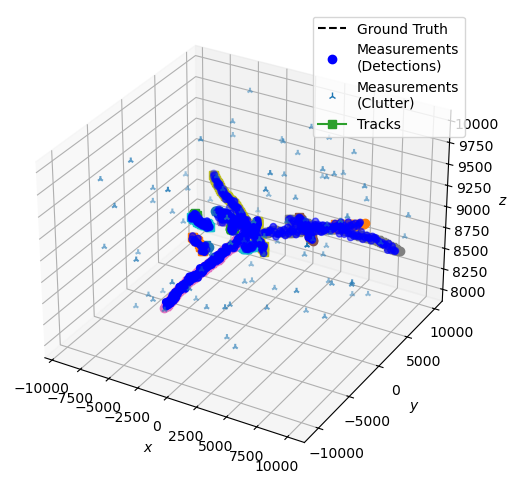

In [71]:
## Plots

from stonesoup.plotter import Plotter, Dimension
plotter = Plotter(Dimension.THREE)
plotter.plot_ground_truths(groundtruth_plot, [0, 2, 4])
plotter.plot_measurements(detections_plot, [0, 2, 4])
_ = plotter.plot_tracks(tracks_plot, [0, 2, 4], uncertainty=False, err_freq=5)

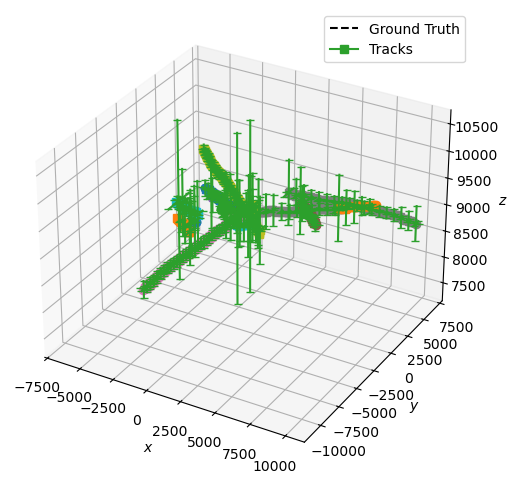

In [72]:
plotter2 = Plotter(Dimension.THREE)
plotter2.plot_ground_truths(groundtruth_plot, [0, 2, 4])
_ = plotter2.plot_tracks(tracks_plot, [0, 2, 4], uncertainty = True, err_freq=5) 

## Metriche di valutazion

Le metriche di valutazione vengono utilizzate per verificare quanto diverse tecniche o diversi sensori siano efficaci. Le metriche utilizzate sono:

1. distanza Optimal SubPattern Assignment (OSPA) per due set di oggetti Tracks, misurata tra due point patterns ed ad ogni timestamp nel quale è presente una Track.
2. Track-to-truth metrics: calcolo delle metriche Single Integrated Air Picture (SIAP).
3. Metriche di incertezza: SumofCovarianceNormsMetric


### OSPA Metrics

Questo tipo di metriche sono descritte in maniera esaustiva in "A Consistent Metric for Performance Evaluation of Multi-Object Filters" di Dominic Schuhmacher, Ba-Tuong Vo, and Ba-Ngu Vo.


### SIAP Metrics

Le metriche SIAP richiedono info sul ground truth.

**Metriche:**

*   **Completeness (C)**: oggetti reali tracciati. L'output è nell'intervallo $0 : 1$, con un punteggio obiettivo di 1.
*   **Ambiguity (A)**: Numero di tracce assegnate a un oggetto reale. L'output è illimitato con un intervallo di $0 : \infty$. Il punteggio obiettivo è 1.
*   **Spuriousness (S)**: Frazione di tracce che non sono assegnate a un oggetto reale. L'output è nell'intervallo $0 : 1$, con un punteggio obiettivo di 0.
*   **Positional Accuracy (PA)**: Errore di posizione delle tracce associate rispetto alle loro rispettive tracce reali. L'output è una misura di distanza, intervallo $0 : \infty$, con un punteggio obiettivo di 0.
*   **Velocity Accuracy (VA)**: Errore di velocità delle tracce associate rispetto alle loro rispettive tracce reali. L'output è una misura di distanza, intervallo $0 : \infty$, con un punteggio obiettivo di 0.
*   **Rate of track number changes (R)**: Misura di continuità SIAP. Tasso del numero di cambi di traccia per numero di tracce vere. L'output è nell'intervallo $0 : \infty$, con un punteggio obiettivo di 0.
*   **Longest track Segment (LS)**: Misura di continuità SIAP. Proporzione del segmento di traccia associato più lungo per tracce vere. L'output è nell'intervallo $0 : 1$, con un punteggio obiettivo di 1.

### SumofCovarianceNormsMetric

Calcola la somma delle norme delle matrici di covarianza di ciascuno stato in un determinato istante temporale. La norma della matrice calcolata è la norma di Frobenius. Il generatore della metrica restituirà questo valore a ogni passo temporale della/e traccia/e come misura dell’incertezza.


Viene definito un associator per il metric MultiManager per associare tracce e truth. Genera le metriche mediante generate_metrics() e restituisce oggetti di tipo Metric


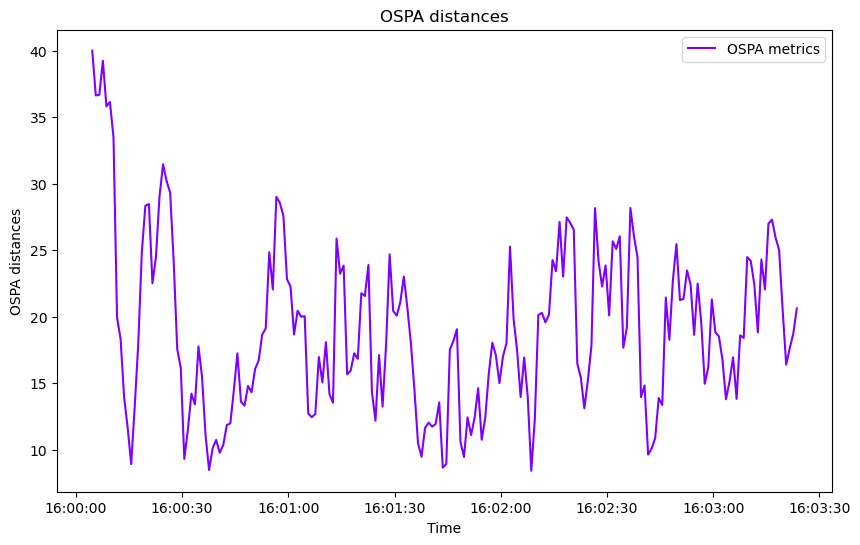

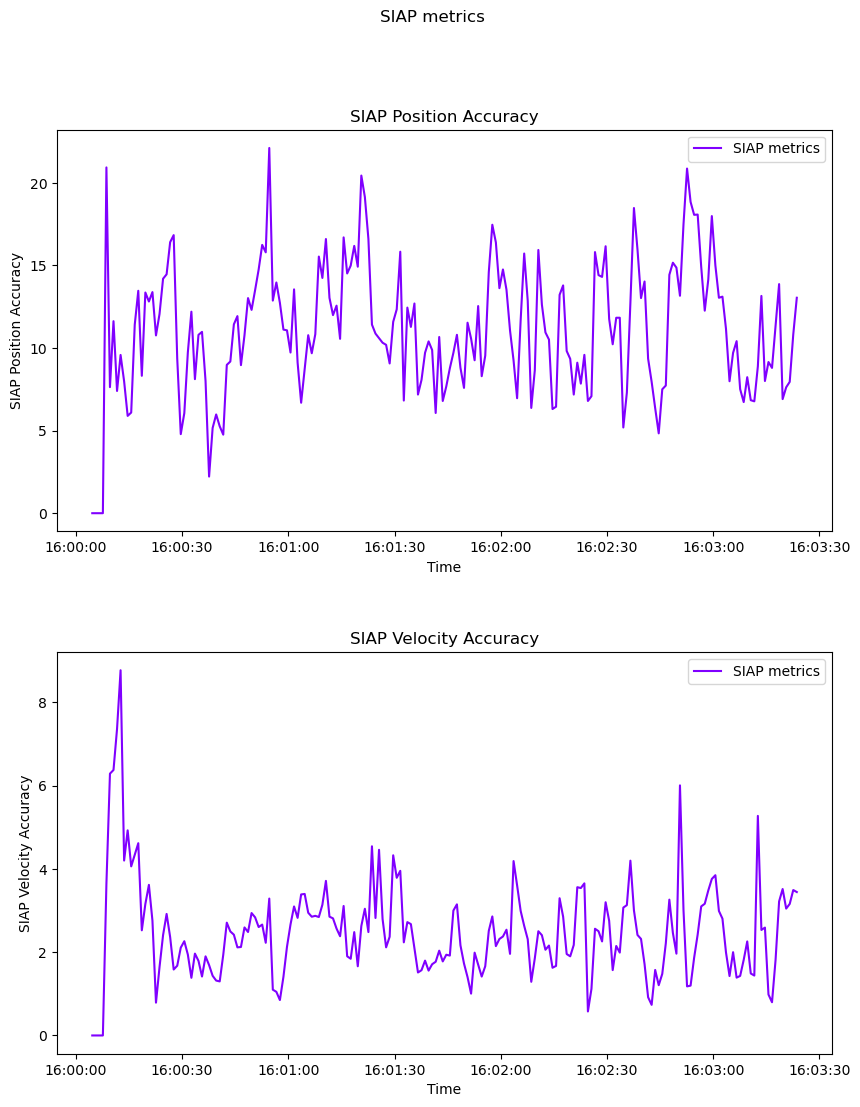

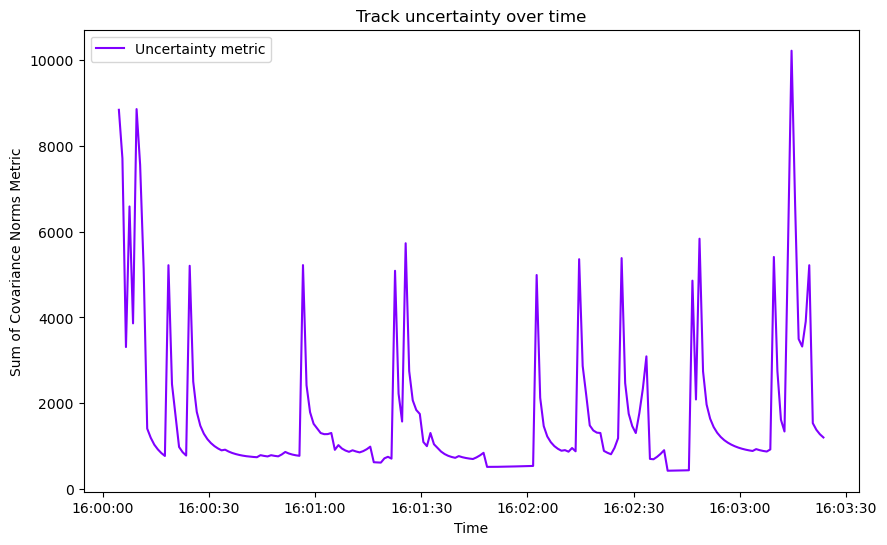

In [73]:
# OSPA metric

from stonesoup.metricgenerator.ospametric import OSPAMetric

ospa_generator = OSPAMetric(
    
    c=40, 
    p=1,
    generator_name='OSPA metrics',
    tracks_key='tracks',
    truths_key='truths'
                        
)

# SIAP metrics

from stonesoup.metricgenerator.tracktotruthmetrics import SIAPMetrics

from stonesoup.measures import Euclidean 

SIAPpos_measure = Euclidean(mapping = np.array([0, 2]))

SIAPvel_measure = Euclidean(mapping = np.array([1, 3]))

siap_generator = SIAPMetrics(
    
    position_measure = SIAPpos_measure, # Distance measure used in calculating position accuracy scores.
    velocity_measure = SIAPvel_measure, # Distance measure used in calculating velocity accuracy scores.
    generator_name = 'SIAP metrics',
    tracks_key = 'tracks',
    truths_key = 'truths'
    
)

# Uncertainty metric

from stonesoup.metricgenerator.uncertaintymetric import SumofCovarianceNormsMetric

uncertainty_generator = SumofCovarianceNormsMetric(generator_name='Uncertainty metric', tracks_key='tracks')

# Compares two sets of Track, each formed of a sequence of State objects and returns an Association object for each time at which two 
# State objects within the Track are assessed to be associated. Tracks are considered to be associated with the Truth if the true State 
# is the closest to the track and within the specified distance for a specified number of time steps.
# Associations between Truth and Track if the Truth is no longer the ‘closest’ to the track or the distance exceeds the specified 
# threshold for a specified number of consecutive time steps.

from stonesoup.dataassociator.tracktotrack import TrackToTruth

associator = TrackToTruth(association_threshold = 30)

from stonesoup.metricgenerator.manager import MultiManager



metric_manager = MultiManager(
    
    [ospa_generator, siap_generator, uncertainty_generator],  # generatori di metriche utilizzate
    associator = associator
    
)

metric_manager.add_data({'truths': groundtruth_plot, 'tracks': tracks_plot})

metrics = metric_manager.generate_metrics()

from stonesoup.plotter import MetricPlotter # class for plottin StoneSoup metrics using matplotlib

fig1 = MetricPlotter()
fig1.plot_metrics(metrics, generator_names=['OSPA metrics'])

fig2 = MetricPlotter()
fig2.plot_metrics(metrics, metric_names=['SIAP Position Accuracy at times',
                                         'SIAP Velocity Accuracy at times'])
fig2.set_fig_title('SIAP metrics')

fig3 = MetricPlotter()

fig3.plot_metrics(metrics, generator_names=['Uncertainty metric'])
fig3.set_ax_title(['Track uncertainty over time'])